In [25]:
import os, random, warnings, csv as _csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [26]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [27]:
def seed_everything(seed=7):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(7)
print('Seed = 7')

Seed = 7


In [ ]:
# CONFIG 

ROCK_CSVS_DIR = os.path.expanduser('~/Desktop/rock_csvs')

NEW_ROCK_CSVS_DIR = os.path.expanduser('~/Desktop/profiles_csv')

NEW_ROCK_FOLDERS = [
    'Dunite-Ecologite_2Rocks_1-83Hz',
    'Gneis_1-83Hz',
    'Granite_3SamplesPhilipp_1-83Hz_1',
    'Granite_3SamplesPhilipp_1-83Hz_2',
    'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz',
    'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz',
    'Limestone_Rax_1-83Hz_1',
    'Limestone_Rax_1-83Hz_2',
    'SandstoneNew_1-83Hz',
]

EXPECTED_CLASS = {
    'Dunite-Ecologite_2Rocks_1-83Hz'               : 'Unknown',
    'Gneis_1-83Hz'                                  : 'S10Granite',
    'Granite_3SamplesPhilipp_1-83Hz_1'              : 'S10Granite',
    'Granite_3SamplesPhilipp_1-83Hz_2'              : 'S10Granite',
    'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz' : 'Leitendorf_Limestone',
    'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz' : 'Leitendorf_Limestone',
    'Limestone_Rax_1-83Hz_1'                        : 'Leitendorf_Limestone',
    'Limestone_Rax_1-83Hz_2'                        : 'Leitendorf_Limestone',
    'SandstoneNew_1-83Hz'                           : 'Holstein_Sandstone',
}

# Autoencoder hyperparameters
SPECTRUM_LEN  = 1060   # number of wavenumber points per spectrum
LATENT_DIM    = 32     # bottleneck dimension
EPOCHS        = 80
LR            = 1e-3
BATCH_SIZE    = 128
TEST_SPLIT    = 0.20
OOD_FPR       = 0.05   # 5% false positive rate on known rocks

CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#59a14f']
OOD_COLOR    = '#e15759'

RESULTS_DIR = 'results_ood_autoencoder_1d'
DIR_TRAIN   = os.path.join(RESULTS_DIR, 'training')
DIR_OOD     = os.path.join(RESULTS_DIR, 'ood_results')
DIR_VIZ     = os.path.join(RESULTS_DIR, 'spectrum_viz')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_OOD, DIR_VIZ]:
    os.makedirs(d, exist_ok=True)

MODEL_PATH = os.path.join(RESULTS_DIR, 'autoencoder_1d_multisource.pth')

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

print('Config ready.')
print(f'  ROCK_CSVS_DIR   = {ROCK_CSVS_DIR}')
print(f'  NEW_ROCKS_DIR   = {NEW_ROCK_CSVS_DIR}')
print(f'  LATENT_DIM      = {LATENT_DIM}')
print(f'  EPOCHS          = {EPOCHS}')
print(f'  OOD_FPR         = {OOD_FPR}')

Config ready.
  ROCK_CSVS_DIR   = /home/puneeth/Desktop/rock_csvs
  NEW_ROCKS_DIR   = /home/puneeth/Desktop/profiles_csv
  LATENT_DIM      = 32
  EPOCHS          = 80
  OOD_FPR         = 0.05


In [ ]:
# INSPECT — list what CSV files are available
print(f'Files in {ROCK_CSVS_DIR}:')
for f in sorted(os.listdir(ROCK_CSVS_DIR)):
    path = os.path.join(ROCK_CSVS_DIR, f)
    size = os.path.getsize(path) // 1024
    print(f'  {f}  ({size} KB)')

Files in /home/puneeth/Desktop/rock_csvs:
  Holstein_Sandstone_1-83Hz_profiles.csv  (106130 KB)
  Holstein_Sandstone_5-10Hz_profiles.csv  (106100 KB)
  Leitendorf_Limestone_1-83Hz_profiles.csv  (107550 KB)
  Leitendorf_Limestone_5-10Hz_profiles.csv  (109328 KB)
  S10Granite_1-83Hz_profiles.csv  (109484 KB)
  S10Granite_5-10Hz_profiles.csv  (113696 KB)


In [ ]:
# CSV LOADER FOR KNOWN ROCKS

def find_csv(csvs_dir, class_name, speed_tag):
    """Find the CSV file for a given class and belt speed."""
    short = class_name.replace('_', '').lower()  
    short2 = class_name.split('_')[0].lower()     
    matches = [
        f for f in os.listdir(csvs_dir)
        if f.endswith('.csv')
        and speed_tag.replace('.', '-') in f.replace('.', '-')
        and (short in f.lower().replace('_','') or
             short2 in f.lower() or
             class_name.lower().replace('_','') in f.lower().replace('_',''))
    ]
    if not matches:
    
        all_csv = [f for f in os.listdir(csvs_dir) if f.endswith('.csv')]
        raise FileNotFoundError(
            f'No CSV found for class="{class_name}" speed="{speed_tag}"\n'
            f'Available files: {all_csv}\n'
            f'Adjust CSV_FILES dict manually if auto-discovery fails.')
    return os.path.join(csvs_dir, sorted(matches)[0])


def load_csv_spectra(csv_path, n_points=SPECTRUM_LEN):
    """Load all spectra from a CSV file. Returns numpy array (N, n_points)."""
    spectra = []
    with open(csv_path, 'r') as f:
        reader = _csv.reader(f)
        for row in reader:
            if len(row) < n_points: continue
            try:
                vals = [float(v.replace(',', '.')) for v in row[:n_points]]
                if all(v == 0 for v in vals): continue  # skip all-zero rows
                if max(vals) >= 3.0: continue            # skip spike rows
                spectra.append(vals)
            except ValueError:
                continue  # skip header rows
    return np.array(spectra, dtype=np.float32)


print('Loading 1.83 Hz CSV spectra...')
spectra_by_class_183 = {}
for cls in CLASS_NAMES:
    try:
        path = find_csv(ROCK_CSVS_DIR, cls, '1-83')
        arr  = load_csv_spectra(path)
        spectra_by_class_183[cls] = arr
        print(f'  {cls}: {arr.shape[0]} spectra from {os.path.basename(path)}')
    except FileNotFoundError as e:
        print(f'  [WARNING] {e}')

print('\nLoading 5.10 Hz CSV spectra...')
spectra_by_class_510 = {}
for cls in CLASS_NAMES:
    try:
        path = find_csv(ROCK_CSVS_DIR, cls, '5-10')
        arr  = load_csv_spectra(path)
        spectra_by_class_510[cls] = arr
        print(f'  {cls}: {arr.shape[0]} spectra from {os.path.basename(path)}')
    except FileNotFoundError as e:
        print(f'  [WARNING] {e}')

# Combine both speeds for training
all_known_spectra = []
all_known_labels  = []
for cls_idx, cls in enumerate(CLASS_NAMES):
    for d in [spectra_by_class_183, spectra_by_class_510]:
        if cls in d:
            all_known_spectra.append(d[cls])
            all_known_labels.extend([cls_idx]*len(d[cls]))

X_known = np.vstack(all_known_spectra)
y_known = np.array(all_known_labels)
print(f'\nTotal known-rock spectra: {X_known.shape[0]} × {X_known.shape[1]} wavenumber points')
print(f'Class distribution: '
      f'{[(cls, int(np.sum(y_known==i))) for i, cls in enumerate(CLASS_NAMES)]}')

Loading 1.83 Hz CSV spectra...
  S10Granite: 8000 spectra from S10Granite_1-83Hz_profiles.csv
  Holstein_Sandstone: 8000 spectra from Holstein_Sandstone_1-83Hz_profiles.csv
  Leitendorf_Limestone: 8108 spectra from Leitendorf_Limestone_1-83Hz_profiles.csv

Loading 5.10 Hz CSV spectra...
  S10Granite: 8310 spectra from S10Granite_5-10Hz_profiles.csv
  Holstein_Sandstone: 8000 spectra from Holstein_Sandstone_5-10Hz_profiles.csv
  Leitendorf_Limestone: 8236 spectra from Leitendorf_Limestone_5-10Hz_profiles.csv

Total known-rock spectra: 48654 × 1060 wavenumber points
Class distribution: [('S10Granite', 16310), ('Holstein_Sandstone', 16000), ('Leitendorf_Limestone', 16344)]


In [31]:
# NOTE: TXT parsing is handled by convert_new_rocks.py
# Run that script first to generate CSVs in ~/Desktop/profiles_csv/
# This notebook loads from those CSVs directly — same format as rock_csvs/
print('TXT conversion handled by convert_new_rocks.py')
print(f'New rock CSVs expected in: {NEW_ROCK_CSVS_DIR}')
print('Files found:')
if os.path.isdir(NEW_ROCK_CSVS_DIR):
    for f in sorted(os.listdir(NEW_ROCK_CSVS_DIR)):
        size = os.path.getsize(os.path.join(NEW_ROCK_CSVS_DIR,f))//1024
        print(f'  {f}  ({size} KB)')
else:
    print(f'  [NOT FOUND] Run convert_new_rocks.py first')

TXT conversion handled by convert_new_rocks.py
New rock CSVs expected in: /home/puneeth/Desktop/profiles_csv
Files found:
  Dunite-Ecologite_2Rocks_1-83Hz.csv  (13256 KB)
  Gneis_1-83Hz.csv  (14564 KB)
  Granite_3SamplesPhilipp_1-83Hz_1.csv  (26394 KB)
  Granite_3SamplesPhilipp_1-83Hz_2.csv  (15638 KB)
  Limestone_CalcsilicaContaminated_U9_U3_1-83Hz.csv  (26581 KB)
  Limestone_CalcsilicaContaminated_U9_U3_5-10Hz.csv  (26572 KB)
  Limestone_Rax_1-83Hz_1.csv  (797 KB)
  Limestone_Rax_1-83Hz_2.csv  (530 KB)
  SandstoneNew_1-83Hz.csv  (132 KB)


In [ ]:
# LOAD ALL NEW ROCK SPECTRA FROM CSV FILES

new_rock_spectra = {}  
new_rock_failed  = []

print('Loading new rock CSV files...')
for fn in NEW_ROCK_FOLDERS:
    csv_path = os.path.join(NEW_ROCK_CSVS_DIR, fn + '.csv')
    if not os.path.exists(csv_path):
        print(f'  [SKIP] {fn} — CSV not found: {csv_path}')
        print(f'         Run convert_new_rocks.py first.')
        new_rock_failed.append(fn)
        continue
    arr = load_csv_spectra(csv_path)
    if arr is None or len(arr) == 0:
        print(f'  [SKIP] {fn} — 0 spectra loaded from CSV')
        new_rock_failed.append(fn)
        continue
    new_rock_spectra[fn] = arr
    exp = EXPECTED_CLASS.get(fn, '?')
    print(f'  {fn}: {arr.shape[0]} spectra  (expected: {exp})')

print(f'\nSuccessfully loaded: {len(new_rock_spectra)} folders')
if new_rock_failed:
    print(f'Failed/skipped: {new_rock_failed}')

Loading new rock CSV files...
  Dunite-Ecologite_2Rocks_1-83Hz: 1000 spectra  (expected: Unknown)
  Gneis_1-83Hz: 1072 spectra  (expected: S10Granite)
  Granite_3SamplesPhilipp_1-83Hz_1: 1992 spectra  (expected: S10Granite)
  Granite_3SamplesPhilipp_1-83Hz_2: 1180 spectra  (expected: S10Granite)
  Limestone_CalcsilicaContaminated_U9_U3_1-83Hz: 2000 spectra  (expected: Leitendorf_Limestone)
  Limestone_CalcsilicaContaminated_U9_U3_5-10Hz: 2000 spectra  (expected: Leitendorf_Limestone)
  Limestone_Rax_1-83Hz_1: 60 spectra  (expected: Leitendorf_Limestone)
  Limestone_Rax_1-83Hz_2: 40 spectra  (expected: Leitendorf_Limestone)
  SandstoneNew_1-83Hz: 10 spectra  (expected: Holstein_Sandstone)

Successfully loaded: 9 folders


In [ ]:
# NORMALIZE SPECTRA

def normalize_spectra(X):
    """Per-spectrum min-max normalization to [0, 1]."""
    mn = X.min(axis=1, keepdims=True)
    mx = X.max(axis=1, keepdims=True)
    denom = mx - mn
    denom[denom == 0] = 1.0  # avoid divide-by-zero for flat spectra
    return (X - mn) / denom


X_known_norm = normalize_spectra(X_known.copy())

# Normalize new rock spectra
new_rock_spectra_norm = {
    fn: normalize_spectra(arr.copy())
    for fn, arr in new_rock_spectra.items()
}

print(f'Known rocks normalized: {X_known_norm.shape}')
for fn, arr in new_rock_spectra_norm.items():
    print(f'  {fn}: {arr.shape}')

Known rocks normalized: (48654, 1060)
  Dunite-Ecologite_2Rocks_1-83Hz: (1000, 1060)
  Gneis_1-83Hz: (1072, 1060)
  Granite_3SamplesPhilipp_1-83Hz_1: (1992, 1060)
  Granite_3SamplesPhilipp_1-83Hz_2: (1180, 1060)
  Limestone_CalcsilicaContaminated_U9_U3_1-83Hz: (2000, 1060)
  Limestone_CalcsilicaContaminated_U9_U3_5-10Hz: (2000, 1060)
  Limestone_Rax_1-83Hz_1: (60, 1060)
  Limestone_Rax_1-83Hz_2: (40, 1060)
  SandstoneNew_1-83Hz: (10, 1060)


[SAVED] results_ood_autoencoder_1d/training/TR-00_sample_spectra__known_and_new_rocks.png


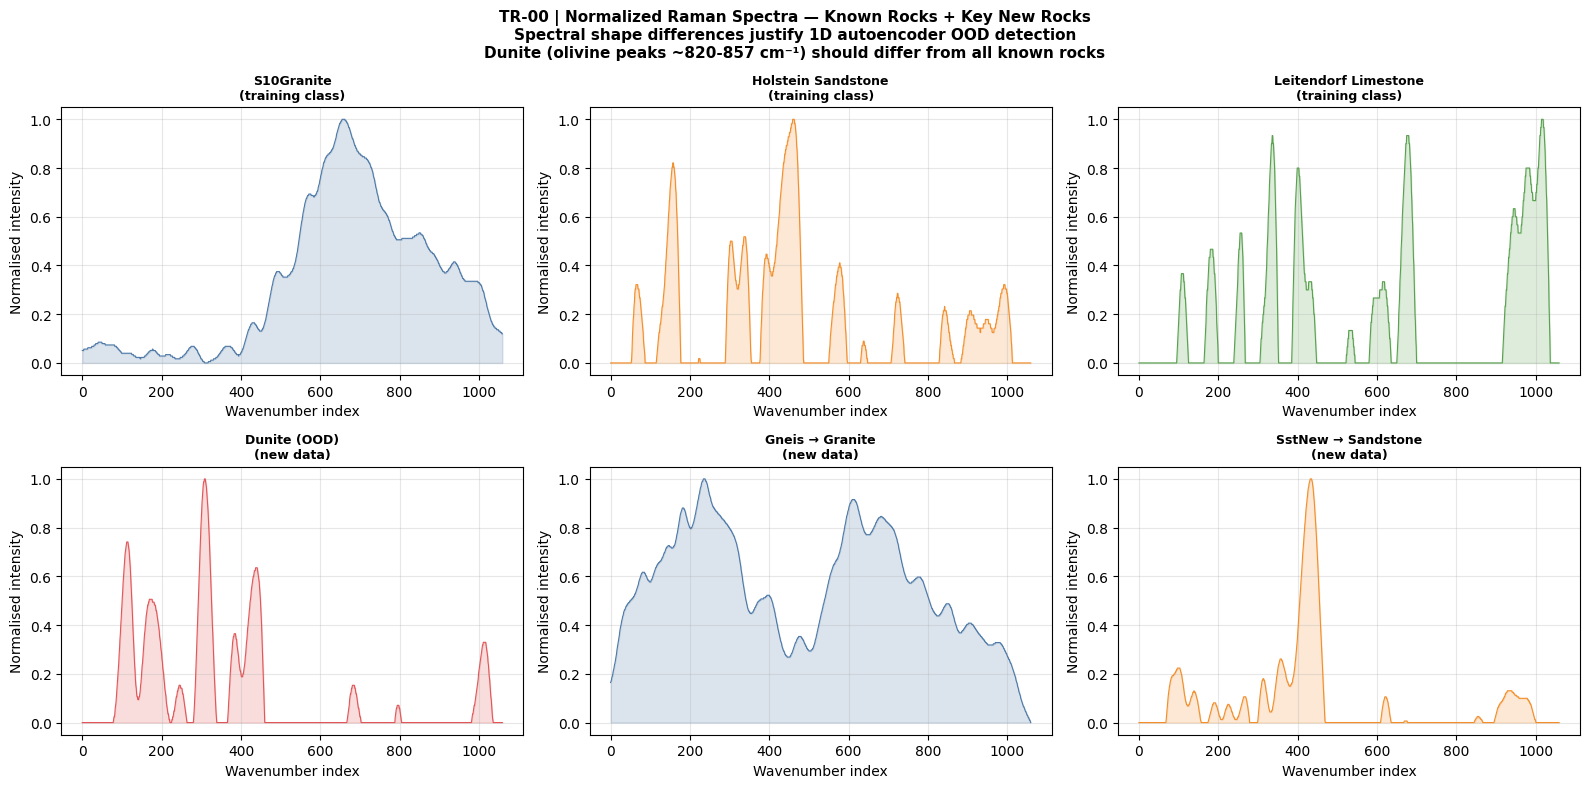

In [ ]:
# TR-00  Sample spectra per class
# What it shows: one representative normalized spectrum per class.
# Visually confirms the spectral shapes are distinct:
# Granite has a broad fluorescence hump, Sandstone/Limestone show sharper peaks.
# Dunite should look different from all three .

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(
    'TR-00 | Normalized Raman Spectra — Known Rocks + Key New Rocks\n'
    'Spectral shape differences justify 1D autoencoder OOD detection\n'
    'Dunite (olivine peaks ~820-857 cm⁻¹) should differ from all known rocks',
    fontsize=11, fontweight='bold')

# Row 1: known rock classes
for ci, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    ax = axes[0][ci]
    idx  = np.where(y_known == ci)[0]
    sample = X_known_norm[idx[len(idx)//2]]
    ax.plot(sample, color=color, lw=0.8)
    ax.fill_between(range(len(sample)), sample, alpha=0.2, color=color)
    ax.set_title(f'{cls.replace("_"," ")}\n(training class)', fontsize=9,
                 fontweight='bold')
    ax.set_xlabel('Wavenumber index'); ax.set_ylabel('Normalised intensity')
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)

# Row 2: Dunite + 2 new rocks for comparison
new_examples = [
    ('Dunite-Ecologite_2Rocks_1-83Hz', OOD_COLOR,  'Dunite (OOD)'),
    ('Gneis_1-83Hz',                   CLASS_COLORS[0], 'Gneis → Granite'),
    ('SandstoneNew_1-83Hz',            CLASS_COLORS[1], 'SstNew → Sandstone'),
]
for col, (fn, color, label) in enumerate(new_examples):
    ax = axes[1][col]
    if fn in new_rock_spectra_norm:
        arr    = new_rock_spectra_norm[fn]
        sample = arr[len(arr)//2]
        ax.plot(sample, color=color, lw=0.8)
        ax.fill_between(range(len(sample)), sample, alpha=0.2, color=color)
        ax.set_title(f'{label}\n(new data)', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{fn}\nnot loaded', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='grey')
    ax.set_xlabel('Wavenumber index'); ax.set_ylabel('Normalised intensity')
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_TRAIN,
    'TR-00_sample_spectra__known_and_new_rocks.png',
    'Representative normalized spectra for known training classes and key new rock folders. '
    'Visual inspection of spectral shape differences that drive OOD detection.')
plt.show()

In [35]:
# AUTOENCODER MODEL

class SpectralAutoencoder(nn.Module):
    def __init__(self, input_dim=1060, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.1),
            nn.Linear(512, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 512),
            nn.LeakyReLU(0.1),
            nn.Linear(512, input_dim),
            nn.Sigmoid(),  # output in [0,1] matching normalized input
        )

    def forward(self, x):
        z   = self.encoder(x)
        out = self.decoder(z)
        return out

    def reconstruction_error(self, x):
        """Per-sample MSE reconstruction error. No gradient."""
        with torch.no_grad():
            out = self.forward(x)
            return ((out - x) ** 2).mean(dim=1)  # shape (N,)


ae = SpectralAutoencoder(input_dim=SPECTRUM_LEN, latent_dim=LATENT_DIM).to(device)
n_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder | Parameters: {n_params:,}')
print(f'  Encoder: {SPECTRUM_LEN} -> 512 -> 128 -> {LATENT_DIM}')
print(f'  Decoder: {LATENT_DIM} -> 128 -> 512 -> {SPECTRUM_LEN}')

Autoencoder | Parameters: 1,227,076
  Encoder: 1060 -> 512 -> 128 -> 32
  Decoder: 32 -> 128 -> 512 -> 1060


In [36]:
# TRAIN AUTOENCODER
# Trained only on known-rock spectra.
# Skips training if MODEL_PATH already exists.

seed_everything(7)

# Train/val split (stratified by class)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_known_norm, y_known, test_size=TEST_SPLIT,
    stratify=y_known, random_state=7)

print(f'Train: {X_tr.shape[0]}  Val: {X_te.shape[0]}')

tr_t   = torch.tensor(X_tr, dtype=torch.float32)
te_t   = torch.tensor(X_te, dtype=torch.float32)
tr_ldr = DataLoader(TensorDataset(tr_t), BATCH_SIZE, shuffle=True)
te_ldr = DataLoader(TensorDataset(te_t), BATCH_SIZE, shuffle=False)

if os.path.exists(MODEL_PATH):
    print(f'[SKIP] {MODEL_PATH} exists — loading saved autoencoder.')
    ae.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    ae.eval()
    tr_losses, te_losses = [], []
else:
    optimizer = torch.optim.Adam(ae.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8)
    criterion = nn.MSELoss()
    tr_losses, te_losses = [], []
    best_loss = float('inf')

    for epoch in range(EPOCHS):
        # Train
        ae.train()
        ep_loss = []
        for (Xb,) in tr_ldr:
            Xb = Xb.to(device)
            optimizer.zero_grad()
            loss = criterion(ae(Xb), Xb)
            loss.backward(); optimizer.step()
            ep_loss.append(loss.item())
        tr_losses.append(float(np.mean(ep_loss)))

        # Validate
        ae.eval()
        vl = []
        with torch.no_grad():
            for (Xb,) in te_ldr:
                vl.append(criterion(ae(Xb.to(device)), Xb.to(device)).item())
        val_loss = float(np.mean(vl))
        te_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(ae.state_dict(), MODEL_PATH)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:>3}/{EPOCHS}  '
                  f'train={tr_losses[-1]:.6f}  val={val_loss:.6f}  '
                  f'{"[SAVED]" if val_loss == best_loss else ""}')

    ae.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    ae.eval()
    print(f'\nBest val loss: {best_loss:.6f}  -> {MODEL_PATH}')

Train: 38923  Val: 9731
[SKIP] results_ood_autoencoder_1d/autoencoder_1d_multisource.pth exists — loading saved autoencoder.


In [37]:
# TR-01  Training history
if tr_losses:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle(
        'TR-01 | Autoencoder Training History\n'
        'MSE reconstruction loss on known-rock spectra\n'
        'Val loss should converge smoothly — no overfitting expected',
        fontsize=11, fontweight='bold')
    ep = range(1, len(tr_losses)+1)
    ax.plot(ep, tr_losses, 'b-', lw=1.5, label='Train loss')
    ax.plot(ep, te_losses, 'r-', lw=1.5, label='Val loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_title(f'Final val loss: {te_losses[-1]:.6f}' if te_losses else '')
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN,
        'TR-01_autoencoder_training_history.png',
        'MSE reconstruction loss per epoch for the 1D spectral autoencoder. '
        'Trained only on known-rock classes.')
    plt.show()
else:
    print('Model loaded from disk — training history not available.')

Model loaded from disk — training history not available.


In [ ]:
# COMPUTE RECONSTRUCTION ERROR ON KNOWN ROCKS
def get_errors(model, X_norm):
    """Compute per-spectrum MSE reconstruction error. Returns numpy array."""
    model.eval()
    t   = torch.tensor(X_norm, dtype=torch.float32)
    ldr = DataLoader(TensorDataset(t), batch_size=256, shuffle=False)
    errors = []
    with torch.no_grad():
        for (Xb,) in ldr:
            err = model.reconstruction_error(Xb.to(device))
            errors.extend(err.cpu().numpy().tolist())
    return np.array(errors)


# Training set errors (used for calibration)
errors_train = get_errors(ae, X_tr)
errors_val   = get_errors(ae, X_te)

threshold = float(np.percentile(errors_val, (1 - OOD_FPR) * 100))

print(f'Known rocks (train) — mean error: {errors_train.mean():.6f}  '
      f'std: {errors_train.std():.6f}')
print(f'Known rocks (val)   — mean error: {errors_val.mean():.6f}  '
      f'std: {errors_val.std():.6f}')
print(f'\nOOD threshold (at {(1-OOD_FPR)*100:.0f}th percentile of val errors): '
      f'{threshold:.6f}')
print(f'Actual FPR on val: '
      f'{np.mean(errors_val > threshold)*100:.2f}%  '
      f'(target: {OOD_FPR*100:.0f}%)')

Known rocks (train) — mean error: 0.003715  std: 0.003979
Known rocks (val)   — mean error: 0.003748  std: 0.004092

OOD threshold (at 95th percentile of val errors): 0.011908
Actual FPR on val: 5.00%  (target: 5%)


[SAVED] results_ood_autoencoder_1d/ood_results/OOD-01_reconstruction_error__known_rocks_per_class.png


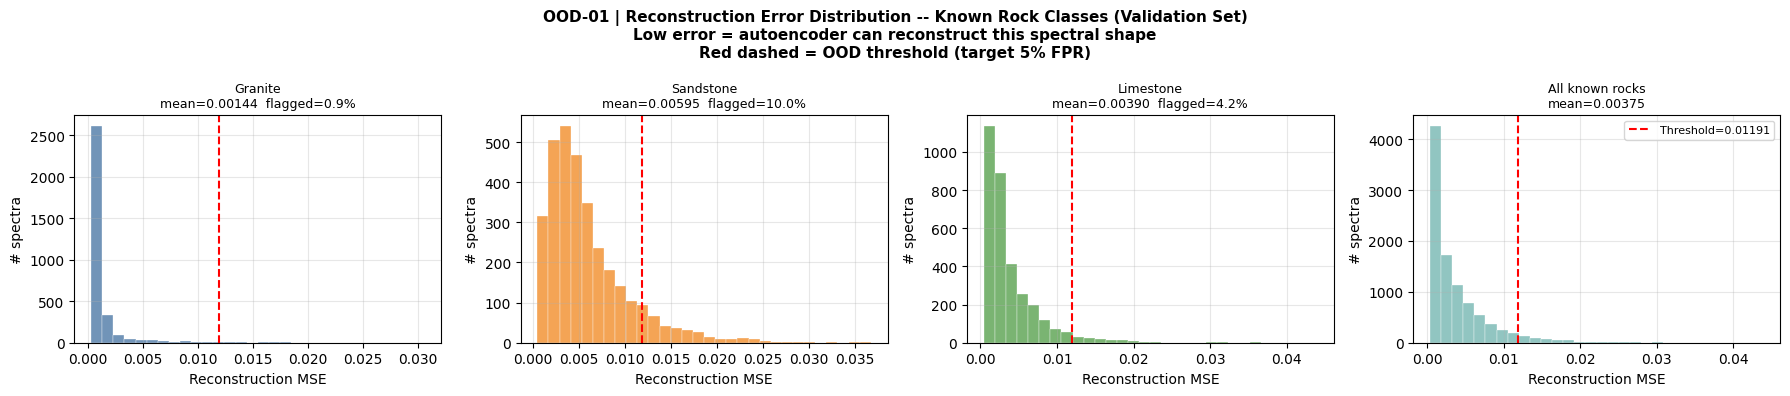

In [39]:
# OOD-01  Error distribution on known rocks per class
# What it shows:
#   Reconstruction error distribution per known rock class.
#   Low error = autoencoder learned to reconstruct this rock type well.
#   Red dashed = OOD threshold. Known rocks should be almost entirely below it.

fig, axes = plt.subplots(1, len(CLASS_NAMES)+1, figsize=(18, 4))
fig.suptitle(
    'OOD-01 | Reconstruction Error Distribution -- Known Rock Classes (Validation Set)\n'
    'Low error = autoencoder can reconstruct this spectral shape\n'
    f'Red dashed = OOD threshold (target {OOD_FPR*100:.0f}% FPR)',
    fontsize=11, fontweight='bold')

for ci, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    ax     = axes[ci]
    mask   = (y_te == ci)
    errs   = errors_val[mask]
    ax.hist(errs, bins=30, color=color, alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(threshold, color='red', ls='--', lw=1.5)
    pct_flagged = np.mean(errs > threshold) * 100
    ax.set_title(f'{SHORT_NAMES[ci]}\n'
                 f'mean={errs.mean():.5f}  flagged={pct_flagged:.1f}%',
                 fontsize=9)
    ax.set_xlabel('Reconstruction MSE'); ax.set_ylabel('# spectra')
    ax.grid(True, alpha=0.3)

# All classes combined
ax = axes[-1]
ax.hist(errors_val, bins=30, color='#76b7b2', alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(threshold, color='red', ls='--', lw=1.5,
           label=f'Threshold={threshold:.5f}')
ax.set_title(f'All known rocks\nmean={errors_val.mean():.5f}', fontsize=9)
ax.set_xlabel('Reconstruction MSE'); ax.set_ylabel('# spectra')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_OOD,
    'OOD-01_reconstruction_error__known_rocks_per_class.png',
    'Reconstruction error distribution per known rock class on validation set. '
    'Shows the in-distribution error range used to calibrate the OOD threshold.')
plt.show()

In [40]:
# COMPUTE RECONSTRUCTION ERRORS FOR ALL NEW ROCK FOLDERS
new_rock_errors = {}  # folder_name -> numpy array of per-spectrum errors

print('Computing reconstruction errors for new rock folders...')
for fn, X_norm in new_rock_spectra_norm.items():
    errors = get_errors(ae, X_norm)
    new_rock_errors[fn] = errors
    n_ood      = np.sum(errors > threshold)
    mean_err   = errors.mean()
    expected   = EXPECTED_CLASS.get(fn, '?')
    verdict    = ''
    if expected == 'Unknown':
        verdict = 'PASS' if n_ood/len(errors) > 0.5 else 'FAIL (not flagged)'
    else:
        verdict = 'PASS' if n_ood/len(errors) < 0.3 else 'WARN (over-flagged)'
    print(f'  {fn}')
    print(f'    n={len(errors)}  mean_err={mean_err:.6f}  '
          f'OOD={n_ood}/{len(errors)} ({n_ood/len(errors)*100:.1f}%)  '
          f'expected={expected}  -> {verdict}')

Computing reconstruction errors for new rock folders...
  Dunite-Ecologite_2Rocks_1-83Hz
    n=1000  mean_err=0.004990  OOD=34/1000 (3.4%)  expected=Unknown  -> FAIL (not flagged)
  Gneis_1-83Hz
    n=1072  mean_err=0.003732  OOD=88/1072 (8.2%)  expected=S10Granite  -> PASS
  Granite_3SamplesPhilipp_1-83Hz_1
    n=1992  mean_err=0.001562  OOD=2/1992 (0.1%)  expected=S10Granite  -> PASS
  Granite_3SamplesPhilipp_1-83Hz_2
    n=1180  mean_err=0.001983  OOD=0/1180 (0.0%)  expected=S10Granite  -> PASS
  Limestone_CalcsilicaContaminated_U9_U3_1-83Hz
    n=2000  mean_err=0.005955  OOD=194/2000 (9.7%)  expected=Leitendorf_Limestone  -> PASS
  Limestone_CalcsilicaContaminated_U9_U3_5-10Hz
    n=2000  mean_err=0.006245  OOD=228/2000 (11.4%)  expected=Leitendorf_Limestone  -> PASS
  Limestone_Rax_1-83Hz_1
    n=60  mean_err=0.003629  OOD=0/60 (0.0%)  expected=Leitendorf_Limestone  -> PASS
  Limestone_Rax_1-83Hz_2
    n=40  mean_err=0.005088  OOD=4/40 (10.0%)  expected=Leitendorf_Limestone  -> PA

[SAVED] results_ood_autoencoder_1d/ood_results/OOD-02_reconstruction_error_comparison__all_groups.png


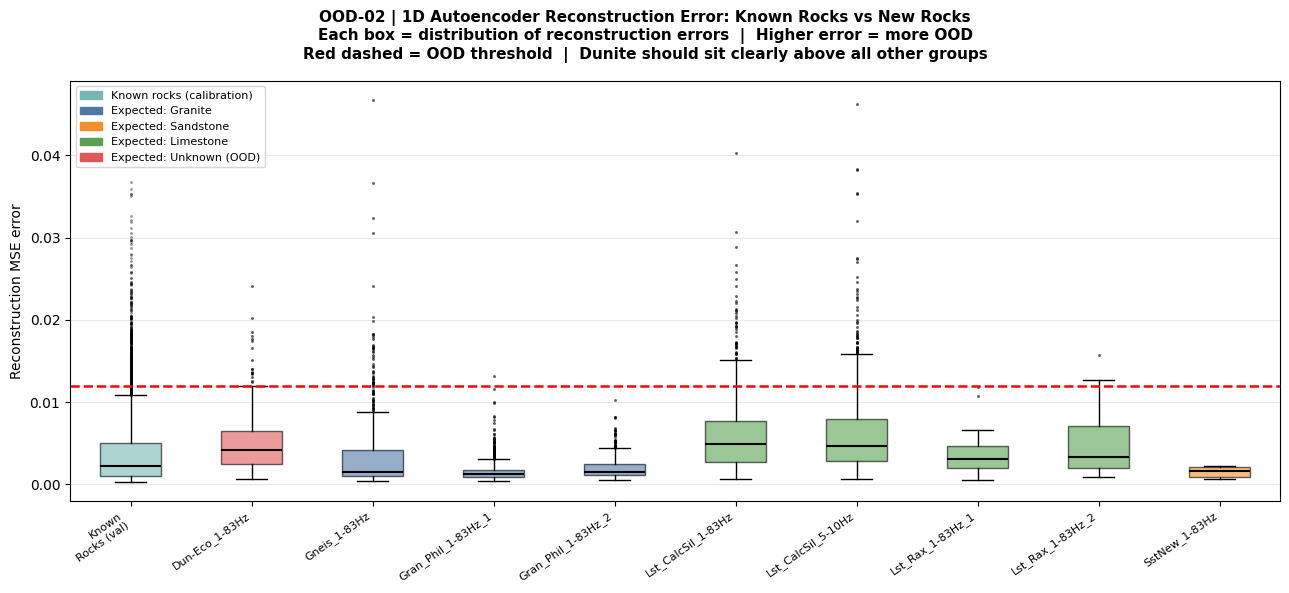

In [ ]:
# OOD-02  Reconstruction error comparison: known rocks vs all new folders
# What it shows:
#   Box plot of reconstruction errors for each group.
#   Known rocks and in-distribution new rocks should cluster BELOW the threshold.
#   Dunite should sit clearly ABOVE it.
#   This is the key result: does the 1D autoencoder separate Dunite from the rest?

all_groups = ['Known\nRocks (val)'] + [
    fn.replace('Limestone_', 'Lst_')
      .replace('Granite_3SamplesPhilipp_', 'Gran_Phil_')
      .replace('SandstoneNew', 'SstNew')
      .replace('Dunite-Ecologite_2Rocks_', 'Dun-Eco_')
      .replace('CalcsilicaContaminated_U9_U3_', 'CalcSil_')
    for fn in new_rock_errors
]
all_data = [errors_val] + list(new_rock_errors.values())

# red for Dunite
def group_color(fn):
    exp = EXPECTED_CLASS.get(fn, '?')
    if exp == 'Unknown':           return OOD_COLOR
    if exp == 'S10Granite':        return CLASS_COLORS[0]
    if exp == 'Holstein_Sandstone':return CLASS_COLORS[1]
    return CLASS_COLORS[2]

colors = ['#76b7b2'] + [group_color(fn) for fn in new_rock_errors]

fig, ax = plt.subplots(figsize=(max(12, len(all_groups)*1.3), 6))
fig.suptitle(
    'OOD-02 | 1D Autoencoder Reconstruction Error: Known Rocks vs New Rocks\n'
    'Each box = distribution of reconstruction errors  |  Higher error = more OOD\n'
    'Red dashed = OOD threshold  |  Dunite should sit clearly above all other groups',
    fontsize=11, fontweight='bold')

bp = ax.boxplot(
    all_data, positions=range(len(all_groups)), patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    whiskerprops=dict(lw=1), capprops=dict(lw=1),
    flierprops=dict(marker='.', markersize=2, alpha=0.4)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)

ax.axhline(threshold, color='red', ls='--', lw=1.8,
           label=f'OOD threshold = {threshold:.5f}')
ax.set_xticks(range(len(all_groups)))
ax.set_xticklabels(all_groups, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Reconstruction MSE error')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# Add legend patches
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='#76b7b2',    label='Known rocks (calibration)'),
    mpatches.Patch(color=CLASS_COLORS[0], label='Expected: Granite'),
    mpatches.Patch(color=CLASS_COLORS[1], label='Expected: Sandstone'),
    mpatches.Patch(color=CLASS_COLORS[2], label='Expected: Limestone'),
    mpatches.Patch(color=OOD_COLOR,    label='Expected: Unknown (OOD)'),
]
ax.legend(handles=handles, fontsize=8, loc='upper left')

plt.tight_layout()
save_fig(fig, DIR_OOD,
    'OOD-02_reconstruction_error_comparison__all_groups.png',
    'Box plot: reconstruction error for known rocks vs all new rock folders. '
    'Dunite should be clearly above the OOD threshold; other new rocks below it.')
plt.show()

[SAVED] results_ood_autoencoder_1d/ood_results/OOD-03_error_histograms__per_new_folder.png


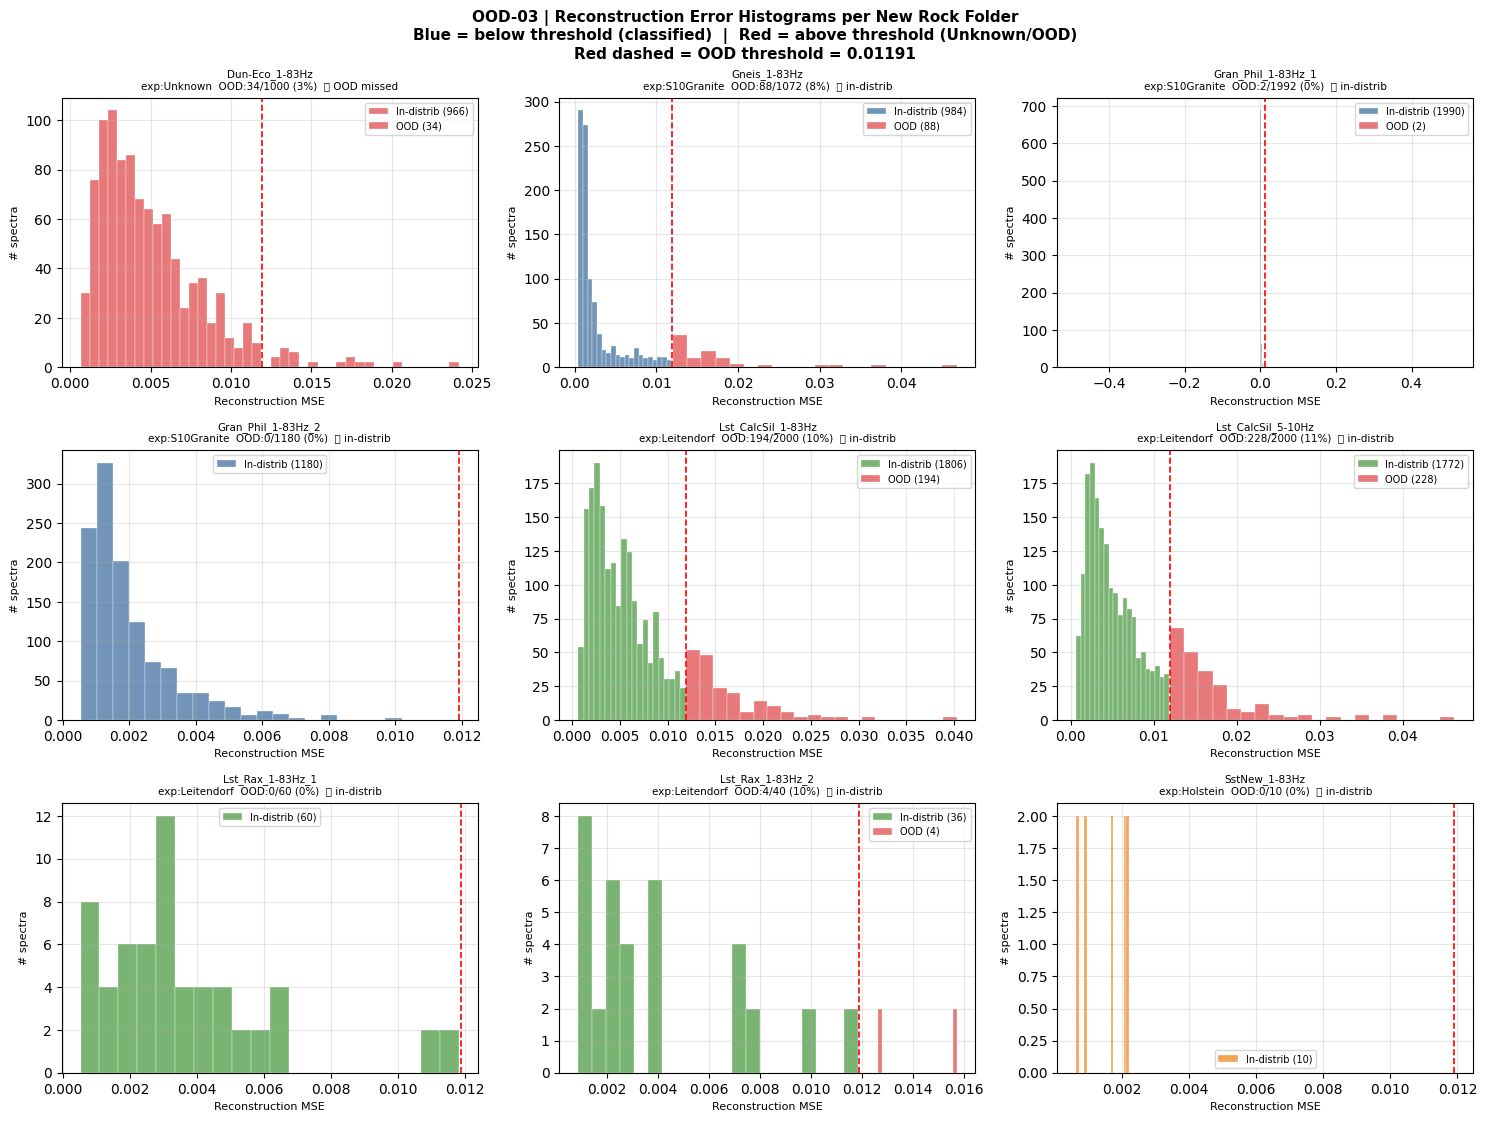

In [42]:
# OOD-03  Error histograms per new folder
# What it shows: per-folder reconstruction error distribution.
# In-distribution rocks: tight low-error spike.
# Dunite: spread distribution shifted right toward high error.

n_new = len(new_rock_errors)
ncols = 3; nrows = int(np.ceil(n_new/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows))
axes = axes.flatten()
fig.suptitle(
    'OOD-03 | Reconstruction Error Histograms per New Rock Folder\n'
    'Blue = below threshold (classified)  |  Red = above threshold (Unknown/OOD)\n'
    f'Red dashed = OOD threshold = {threshold:.5f}',
    fontsize=11, fontweight='bold')

for i, (fn, errors) in enumerate(new_rock_errors.items()):
    ax      = axes[i]
    exp     = EXPECTED_CLASS.get(fn, '?')
    color   = group_color(fn)
    n_ood   = np.sum(errors > threshold)
    cls_e   = errors[errors <= threshold]
    ood_e   = errors[errors >  threshold]
    lbl     = (fn.replace('Limestone_','Lst_')
                 .replace('Granite_3SamplesPhilipp_','Gran_Phil_')
                 .replace('SandstoneNew','SstNew')
                 .replace('Dunite-Ecologite_2Rocks_','Dun-Eco_')
                 .replace('CalcsilicaContaminated_U9_U3_','CalcSil_'))
    if len(cls_e): ax.hist(cls_e, bins=20, color=color, alpha=0.8,
                            label=f'In-distrib ({len(cls_e)})', edgecolor='white', lw=0.3)
    if len(ood_e): ax.hist(ood_e, bins=20, color=OOD_COLOR, alpha=0.8,
                            label=f'OOD ({len(ood_e)})', edgecolor='white', lw=0.3)
    ax.axvline(threshold, color='red', ls='--', lw=1.2)
    verdict = ('\u2705 OOD detected' if exp=='Unknown' and n_ood/len(errors)>0.5
               else '\u274c OOD missed' if exp=='Unknown'
               else '\u2705 in-distrib' if n_ood/len(errors)<0.3
               else '\u26a0 over-flagged')
    ax.set_title(f'{lbl}\nexp:{exp.split("_")[0]}  '
                 f'OOD:{n_ood}/{len(errors)} ({n_ood/len(errors)*100:.0f}%)  '
                 f'{verdict}',
                 fontsize=7.5)
    ax.set_xlabel('Reconstruction MSE', fontsize=8)
    ax.set_ylabel('# spectra', fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

for ax in axes[n_new:]: ax.set_visible(False)
plt.tight_layout()
save_fig(fig, DIR_OOD,
    'OOD-03_error_histograms__per_new_folder.png',
    'Per-folder reconstruction error histograms. '
    'Blue = classified as in-distribution, Red = flagged as Unknown.')
plt.show()

[SAVED] results_ood_autoencoder_1d/spectrum_viz/VIZ-01_reconstruction_comparison__known_rocks_vs_dunite.png


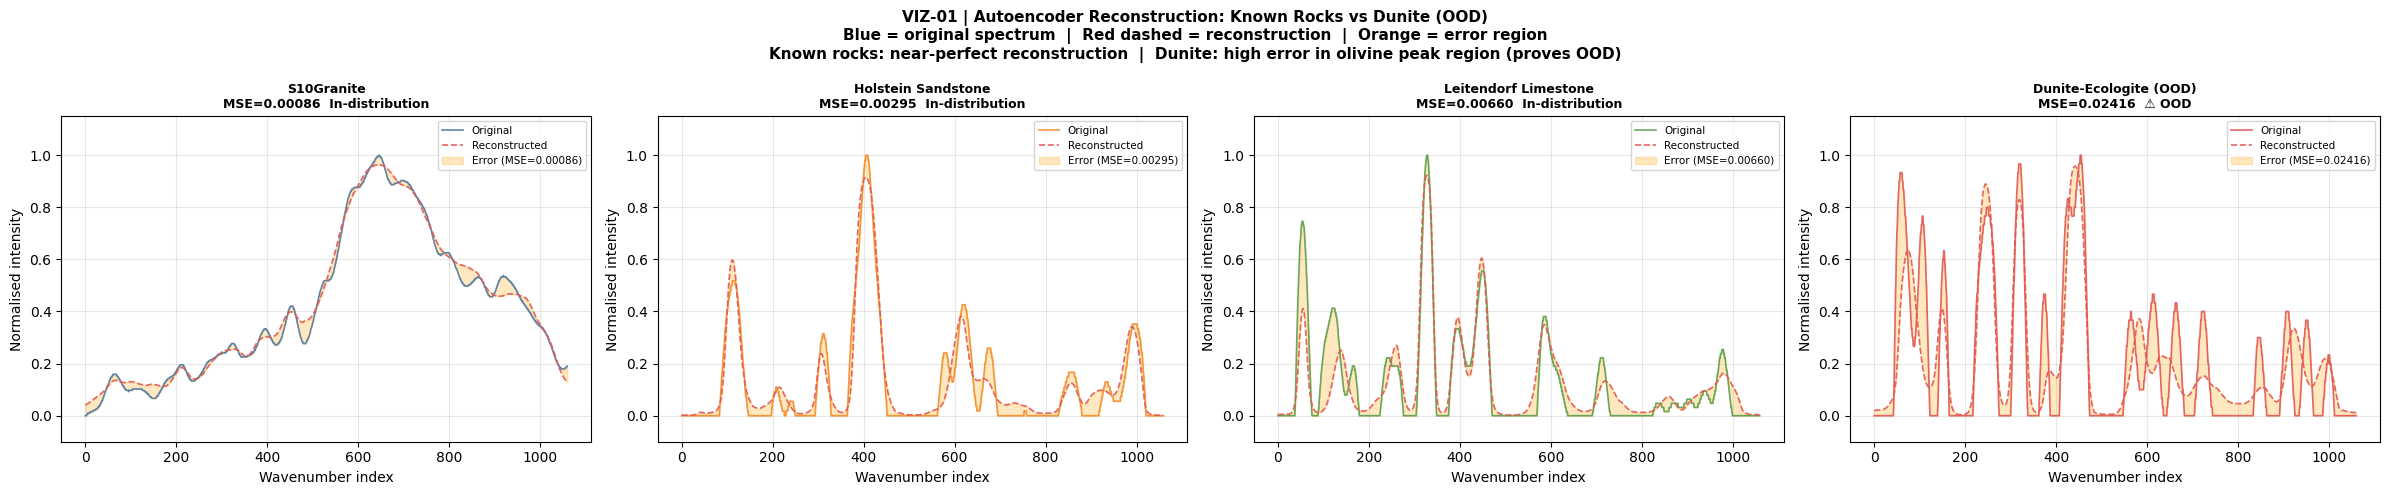

In [ ]:
# VIZ-01  Visual reconstruction: known rock vs Dunite
# What it shows:
#   For a known rock: original spectrum (blue) vs autoencoder reconstruction (red).
#   They should be almost identical — low reconstruction error.
#   For Dunite: reconstruction will fail to reproduce the olivine peaks,
#   producing high error in the ~820-857 cm⁻¹ region.
#   This is the most intuitive visualisation of why the autoencoder catches Dunite.

ae.eval()

def plot_reconstruction(ax, spectrum_norm, model, color, title):
    t    = torch.tensor(spectrum_norm, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(t).cpu().numpy().squeeze()
    err = float(((recon - spectrum_norm)**2).mean())
    ax.plot(spectrum_norm, color=color,     lw=1.2, label='Original', alpha=0.9)
    ax.plot(recon,         color='#e15759', lw=1.2, label='Reconstructed', ls='--', alpha=0.9)
    ax.fill_between(range(len(spectrum_norm)),
                    spectrum_norm, recon, alpha=0.25, color='orange',
                    label=f'Error (MSE={err:.5f})')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Wavenumber index'); ax.set_ylabel('Normalised intensity')
    ax.set_ylim(-0.1, 1.15); ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)
    return err


# Pick one sample per known class + Dunite
sample_list = []
for ci, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    idx = np.where(y_te == ci)[0]
    sample_list.append((X_te[idx[len(idx)//2]], color, cls.replace('_',' ')))

if 'Dunite-Ecologite_2Rocks_1-83Hz' in new_rock_spectra_norm:
    dun = new_rock_spectra_norm['Dunite-Ecologite_2Rocks_1-83Hz']
    dun_errs = get_errors(ae, dun)
    worst_dun = dun[np.argmax(dun_errs)]
    sample_list.append((worst_dun, OOD_COLOR, 'Dunite-Ecologite (OOD)'))

fig, axes = plt.subplots(1, len(sample_list), figsize=(6*len(sample_list), 5))
if len(sample_list) == 1: axes = [axes]
fig.suptitle(
    'VIZ-01 | Autoencoder Reconstruction: Known Rocks vs Dunite (OOD)\n'
    'Blue = original spectrum  |  Red dashed = reconstruction  |  '
    'Orange = error region\n'
    'Known rocks: near-perfect reconstruction  |  '
    'Dunite: high error in olivine peak region (proves OOD)',
    fontsize=11, fontweight='bold')

for ax, (spec, color, title) in zip(axes, sample_list):
    err = plot_reconstruction(ax, spec, ae, color, title)
    ood_flag = '\u26a0 OOD' if err > threshold else 'In-distribution'
    ax.set_title(f'{title}\nMSE={err:.5f}  {ood_flag}', fontsize=9, fontweight='bold')

plt.tight_layout()
save_fig(fig, DIR_VIZ,
    'VIZ-01_reconstruction_comparison__known_rocks_vs_dunite.png',
    'Autoencoder reconstruction overlaid on original spectrum for known rocks and Dunite. '
    'Orange region = reconstruction error. Dunite shows high error in its olivine peak region.')
plt.show()

[SAVED] results_ood_autoencoder_1d/spectrum_viz/VIZ-02_dunite_best_median_worst_reconstruction.png


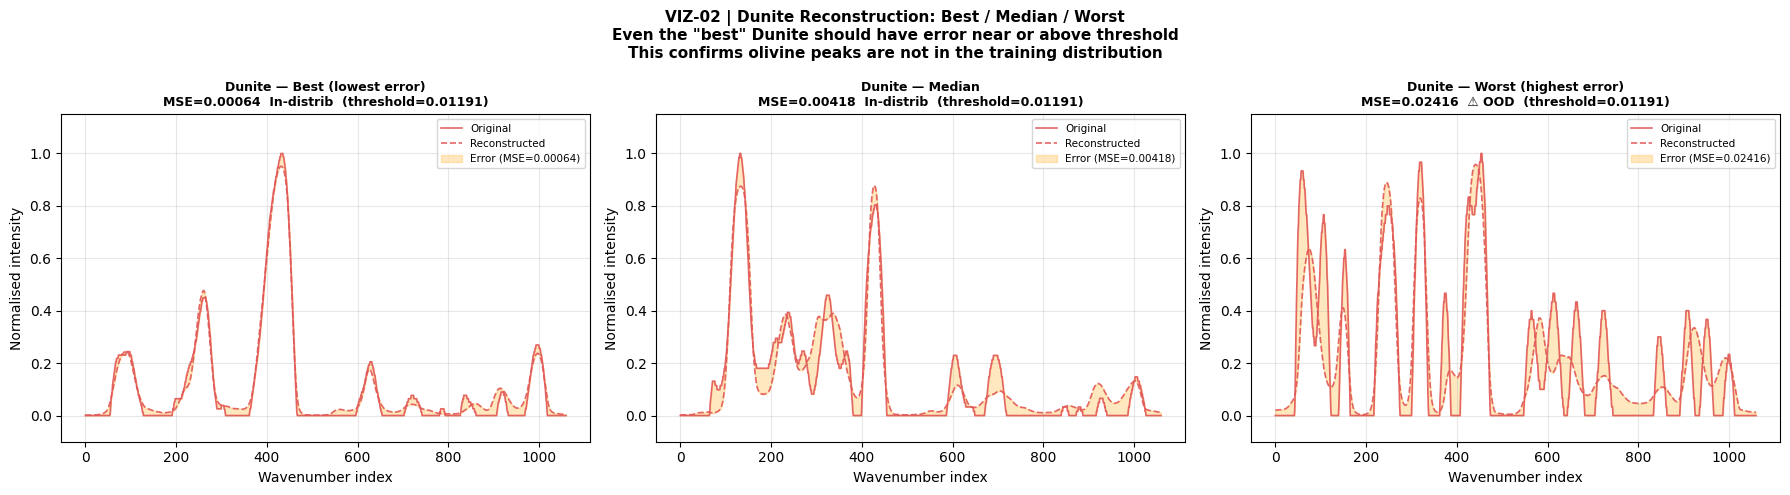

In [44]:
# VIZ-02  Best vs worst Dunite reconstructions
# What it shows: the Dunite spectra with LOWEST and HIGHEST reconstruction error.
# Even the 'best' Dunite should have error near or above the threshold.
# The 'worst' Dunite should show clear failure regions.

if 'Dunite-Ecologite_2Rocks_1-83Hz' in new_rock_spectra_norm:
    dun_norm = new_rock_spectra_norm['Dunite-Ecologite_2Rocks_1-83Hz']
    dun_errs = get_errors(ae, dun_norm)

    best_idx  = np.argmin(dun_errs)
    worst_idx = np.argmax(dun_errs)
    median_idx = np.argsort(dun_errs)[len(dun_errs)//2]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        'VIZ-02 | Dunite Reconstruction: Best / Median / Worst\n'
        'Even the "best" Dunite should have error near or above threshold\n'
        'This confirms olivine peaks are not in the training distribution',
        fontsize=11, fontweight='bold')

    for ax, idx, label in zip(axes,
                               [best_idx, median_idx, worst_idx],
                               ['Best (lowest error)', 'Median', 'Worst (highest error)']):
        plot_reconstruction(ax, dun_norm[idx], ae, OOD_COLOR,
                            f'Dunite — {label}')
        err   = dun_errs[idx]
        flag  = '\u26a0 OOD' if err > threshold else 'In-distrib'
        ax.set_title(f'Dunite — {label}\nMSE={err:.5f}  {flag}  '
                     f'(threshold={threshold:.5f})',
                     fontsize=9, fontweight='bold')

    plt.tight_layout()
    save_fig(fig, DIR_VIZ,
        'VIZ-02_dunite_best_median_worst_reconstruction.png',
        'Dunite spectra with lowest, median, and highest reconstruction error. '
        'Shows that even the easiest Dunite spectrum is near or above the OOD threshold.')
    plt.show()
else:
    print('Dunite data not loaded — skip VIZ-02.')

In [45]:
# FINAL SUMMARY TABLE
print(f'\n{"="*90}')
print('1D AUTOENCODER OOD DETECTION — FINAL RESULTS')
print(f'Threshold = {threshold:.6f}  (at {(1-OOD_FPR)*100:.0f}th percentile of val errors)')
print(f'{"="*90}')
print(f'{"Folder":<48} {"Expected":<12} {"Mean MSE":>9} '
      f'{"OOD%":>7}  Verdict')
print('-'*90)

# Known rocks first
print(f'{"Known rocks (validation split)":<48} {"Known":<12} '
      f'{errors_val.mean():>9.6f} '
      f'{np.mean(errors_val>threshold)*100:>6.1f}%  '
      f'\u2705 Calibration base')
print()

all_verdicts = []
for fn, errors in new_rock_errors.items():
    exp    = EXPECTED_CLASS.get(fn, '?')
    pct    = np.mean(errors > threshold) * 100
    mean_e = errors.mean()
    lbl    = (fn.replace('Limestone_','Lst_')
                .replace('Granite_3SamplesPhilipp_','Gran_Phil_')
                .replace('SandstoneNew','SstNew')
                .replace('Dunite-Ecologite_2Rocks_','Dun-Eco_')
                .replace('CalcsilicaContaminated_U9_U3_','CalcSil_'))

    if exp == 'Unknown':
        verdict = '\u2705 Correctly OOD' if pct > 50 else '\u274c OOD missed'
    else:
        verdict = '\u2705 In-distribution' if pct < 20 else \
                  '\u26a0 Slightly over-flagged' if pct < 40 else \
                  '\u274c Over-flagged'
    all_verdicts.append(verdict)
    print(f'{lbl:<48} {exp.split("_")[0]:<12} {mean_e:>9.6f} '
          f'{pct:>6.1f}%  {verdict}')

print(f'{"="*90}')
correct  = sum(1 for v in all_verdicts if '\u2705' in v)
incorrect = sum(1 for v in all_verdicts if '\u274c' in v)
warning   = sum(1 for v in all_verdicts if '\u26a0' in v)
print(f'\nOutcome: {correct} correct  {incorrect} incorrect  {warning} warnings '
      f'out of {len(all_verdicts)} new rock folders')


1D AUTOENCODER OOD DETECTION — FINAL RESULTS
Threshold = 0.011908  (at 95th percentile of val errors)
Folder                                           Expected      Mean MSE    OOD%  Verdict
------------------------------------------------------------------------------------------
Known rocks (validation split)                   Known         0.003748    5.0%  ✅ Calibration base

Dun-Eco_1-83Hz                                   Unknown       0.004990    3.4%  ❌ OOD missed
Gneis_1-83Hz                                     S10Granite    0.003732    8.2%  ✅ In-distribution
Gran_Phil_1-83Hz_1                               S10Granite    0.001562    0.1%  ✅ In-distribution
Gran_Phil_1-83Hz_2                               S10Granite    0.001983    0.0%  ✅ In-distribution
Lst_CalcSil_1-83Hz                               Leitendorf    0.005955    9.7%  ✅ In-distribution
Lst_CalcSil_5-10Hz                               Leitendorf    0.006245   11.4%  ✅ In-distribution
Lst_Rax_1-83Hz_1           

[SAVED] results_ood_autoencoder_1d/ood_results/OOD-04_roc_curve__dunite_vs_known_rocks.png


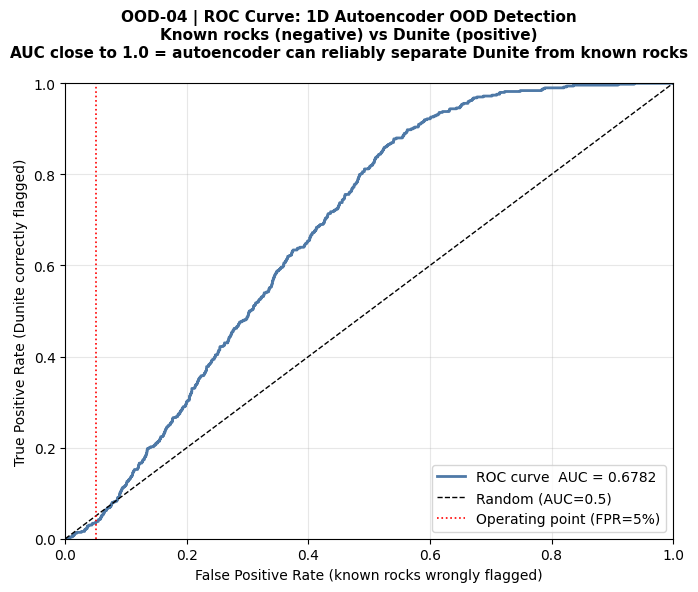

AUC = 0.6782
POOR: Dunite energy overlaps with known rocks — spectral shapes similar.


In [46]:
# OOD-04  ROC curve: can the autoencoder separate Dunite from all known rocks?
# What it shows: at every possible threshold, the True Positive Rate (Dunite caught)
# vs False Positive Rate (known rocks wrongly flagged).
# AUC close to 1.0 = near-perfect separation. AUC = 0.5 = random.

if 'Dunite-Ecologite_2Rocks_1-83Hz' in new_rock_errors:
    ood_errors = new_rock_errors['Dunite-Ecologite_2Rocks_1-83Hz']

    # Binary labels: 0 = known rock, 1 = Dunite (OOD)
    y_roc   = np.concatenate([np.zeros(len(errors_val)),
                               np.ones(len(ood_errors))])
    score   = np.concatenate([errors_val, ood_errors])
    fpr, tpr, _ = roc_curve(y_roc, score)
    auc         = roc_auc_score(y_roc, score)

    fig, ax = plt.subplots(figsize=(7, 6))
    fig.suptitle(
        'OOD-04 | ROC Curve: 1D Autoencoder OOD Detection\n'
        'Known rocks (negative) vs Dunite (positive)\n'
        'AUC close to 1.0 = autoencoder can reliably separate Dunite from known rocks',
        fontsize=11, fontweight='bold')
    ax.plot(fpr, tpr, color='#4e79a7', lw=2,
            label=f'ROC curve  AUC = {auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5)')
    ax.axvline(OOD_FPR, color='red', ls=':', lw=1.2,
               label=f'Operating point (FPR={OOD_FPR*100:.0f}%)')
    ax.set_xlabel('False Positive Rate (known rocks wrongly flagged)')
    ax.set_ylabel('True Positive Rate (Dunite correctly flagged)')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    save_fig(fig, DIR_OOD,
        'OOD-04_roc_curve__dunite_vs_known_rocks.png',
        'ROC curve for 1D autoencoder OOD detection: known rocks vs Dunite. '
        'AUC measures how well reconstruction error separates Dunite from all known rocks.')
    plt.show()
    print(f'AUC = {auc:.4f}')
    if auc > 0.85: print('GOOD: Autoencoder reliably separates Dunite from known rocks.')
    elif auc > 0.70: print('MODERATE: Some separation but overlap exists.')
    else: print('POOR: Dunite energy overlaps with known rocks — spectral shapes similar.')
else:
    print('Dunite not loaded — skip ROC curve.')

In [47]:
# SAVE OOD RESULTS CSV
csv_path = os.path.join(RESULTS_DIR, 'ood_results_1d_autoencoder.csv')
with open(csv_path, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['folder','expected_class','n_spectra','mean_mse_error',
                'pct_ood_flagged','ood_threshold','verdict'])
    # Known rocks
    w.writerow(['Known rocks (val)', 'Known', len(errors_val),
                round(float(errors_val.mean()),8),
                round(float(np.mean(errors_val>threshold)*100),2),
                round(threshold,8), 'Calibration'])
    # New rocks
    for fn, errors in new_rock_errors.items():
        exp  = EXPECTED_CLASS.get(fn,'?')
        pct  = float(np.mean(errors>threshold)*100)
        if exp == 'Unknown':
            v = 'Correctly OOD' if pct>50 else 'OOD missed'
        else:
            v = 'In-distribution' if pct<20 else 'Over-flagged'
        w.writerow([fn, exp, len(errors),
                    round(float(errors.mean()),8),
                    round(pct,2), round(threshold,8), v])
_saved_files.append((csv_path, 'Per-folder OOD results: mean error, % flagged, verdict'))
print(f'[SAVED] {csv_path}')

# RESULTS INDEX
idx_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
with open(idx_path,'w') as f:
    f.write('RESULTS INDEX -- ood_autoencoder_1d\n'+'='*70+'\n')
    f.write(f'SPECTRUM_LEN={SPECTRUM_LEN}  LATENT_DIM={LATENT_DIM}\n')
    f.write(f'EPOCHS={EPOCHS}  LR={LR}  OOD_FPR={OOD_FPR}\n')
    f.write(f'OOD threshold: {threshold:.8f}\n')
    f.write('='*70+'\n\n')
    groups = {'training':[], 'ood_results':[], 'spectrum_viz':[], '(root)':[]}
    for path, desc in _saved_files:
        placed = False
        for key in list(groups.keys())[:-1]:
            if key in path: groups[key].append((path,desc)); placed=True; break
        if not placed: groups['(root)'].append((path,desc))
    labels = {'training':'PHASE 1 -- Training',
              'ood_results':'PHASE 2-4 -- OOD Detection',
              'spectrum_viz':'PHASE 3 -- Spectrum Visualisation',
              '(root)':'ROOT FILES'}
    for key, entries in groups.items():
        if not entries: continue
        f.write(labels[key]+'\n'+'-'*70+'\n')
        for path, desc in entries:
            f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')
        f.write('\n')
print(f'[SAVED] {idx_path}')
print(f'Total files: {len(_saved_files)}')
with open(idx_path) as f: print('\n'+f.read())

[SAVED] results_ood_autoencoder_1d/ood_results_1d_autoencoder.csv
[SAVED] results_ood_autoencoder_1d/RESULTS_INDEX.txt
Total files: 8

RESULTS INDEX -- ood_autoencoder_1d
SPECTRUM_LEN=1060  LATENT_DIM=32
EPOCHS=80  LR=0.001  OOD_FPR=0.05
OOD threshold: 0.01190767

PHASE 1 -- Training
----------------------------------------------------------------------
  TR-00_sample_spectra__known_and_new_rocks.png
    Representative normalized spectra for known training classes and key new rock folders. Visual inspection of spectral shape differences that drive OOD detection.


PHASE 2-4 -- OOD Detection
----------------------------------------------------------------------
  OOD-01_reconstruction_error__known_rocks_per_class.png
    Reconstruction error distribution per known rock class on validation set. Shows the in-distribution error range used to calibrate the OOD threshold.

  OOD-02_reconstruction_error_comparison__all_groups.png
    Box plot: reconstruction error for known rocks vs all new r